<div style="background: linear-gradient(135deg, #73d2de 0%, #218fa3 100%); padding: 25px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin-bottom: 20px;">
    <h1 style="color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; font-weight: 700; margin: 0; font-size: 32px; letter-spacing: 1px;">Demand Forecasting — EDA</h1>
    <p style="color: #E9FAFC; font-style: italic; font-size: 15px; margin: 8px 0 0 0;">Exploratory Data Analysis on Store & Item Sales, Trends, Seasonality, and Outlier Candidates</p>
</div>

<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">1. Loading Data</h2>
</div>

In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/erogluegemen/demand-forecasting-dataset/sample_submission.csv
/kaggle/input/datasets/erogluegemen/demand-forecasting-dataset/train.csv
/kaggle/input/datasets/erogluegemen/demand-forecasting-dataset/test.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/kaggle/input/datasets/erogluegemen/demand-forecasting-dataset/train.csv")
df.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">2. Understanding Data</h2>
</div>

In [4]:
df.shape

(913000, 4)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 913000 entries, 0 to 912999
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   date    913000 non-null  object
 1   store   913000 non-null  int64 
 2   item    913000 non-null  int64 
 3   sales   913000 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 27.9+ MB


In [6]:
df.describe()

,store,item,sales
count,913000.000000,913000.000000,913000.000000
mean,5.500000,25.500000,52.250287
std,2.872283,14.430878,28.801144
min,1.000000,1.000000,0.000000
25%,3.000000,13.000000,30.000000
50%,5.500000,25.500000,47.000000
75%,8.000000,38.000000,70.000000
max,10.000000,50.000000,231.000000


In [7]:
df.sample()

,date,store,item,sales
790052,2016-05-05,3,44,47


In [8]:
# Total sales of each item
arr = df.groupby("item")["sales"].sum()
arr

item
1      401384
2     1069564
3      669087
4      401907
5      335230
6     1068281
7     1068777
8     1405108
9      938379
10    1337133
11    1271925
12    1271534
13    1539621
14    1071531
15    1607442
16     468480
17     602486
18    1538876
19     736892
20     867641
21     736190
22    1469971
23     534979
24    1205975
25    1473334
26     869981
27     402628
28    1604713
29    1271240
30     736554
31    1070845
32     803107
33    1270183
34     469935
35    1201541
36    1406548
37     534258
38    1470330
39     801311
40     534094
41     401759
42     669925
43     936635
44     536811
45    1471467
46    1070764
47     401781
48     937703
49     535663
50    1203009
Name: sales, dtype: int64

In [9]:
arr.max()

1607442

In [10]:
max_sales_item = arr.argmax() + 1
max_sales_item

np.int64(15)

In [11]:
df.groupby("store").count()

,date,item,sales
store,,,
1,91300,91300,91300
2,91300,91300,91300
3,91300,91300,91300
4,91300,91300,91300
5,91300,91300,91300
6,91300,91300,91300
7,91300,91300,91300
8,91300,91300,91300
9,91300,91300,91300


In [12]:
df.groupby("date").count()

,store,item,sales
date,,,
2013-01-01,500,500,500
2013-01-02,500,500,500
2013-01-03,500,500,500
2013-01-04,500,500,500
2013-01-05,500,500,500
...,...,...,...
2017-12-27,500,500,500
2017-12-28,500,500,500
2017-12-29,500,500,500


In [13]:
df.isnull().sum()

date     0
store    0
item     0
sales    0
dtype: int64

In [14]:
df.duplicated().sum()

np.int64(0)

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Total number of distinct items = 50.</li>
        <li>Item with maximum total sales = Item 15.</li>
        <li>Total number of stores = 10.</li>
        <li>Dataset spans 1826 days (2013–2017).</li>
        <li>No null or missing values.</li>
        <li>No duplicate rows.</li>
    </ol>
</div>

<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h3 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 18px; font-weight: 600;">About the Dataset</h3>
</div>

<div style="background-color: #EFFAFB; border-left: 4px solid #73d2de; padding: 10px 15px; border-radius: 0 6px 6px 0; margin: 10px 0;">
    <p style="margin: 0; color: #334E68; font-size: 14px;"><b>Note:</b> It is a time series dataset having 913,000 rows &times; 4 columns. Features include <b>date</b>, <b>item</b> (50 items), <b>store</b> (10 stores), and <b>sales</b>. It has no missing or duplicate values, with dates spanning 1826 days from 2013–2017.</p>
</div>

In [15]:
# Converting object into datetime datatype and sorting them
df["date"] = pd.to_datetime(df["date"])
df.sort_values("date", inplace=True)
df

,date,store,item,sales
0,2013-01-01,1,1,13
211816,2013-01-01,7,12,26
832656,2013-01-01,7,46,27
213642,2013-01-01,8,12,54
215468,2013-01-01,9,12,35
...,...,...,...,...
619013,2017-12-31,9,34,21
620839,2017-12-31,10,34,32
622665,2017-12-31,1,35,55
598927,2017-12-31,8,33,100


<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">3. Data Visualization</h2>
</div>

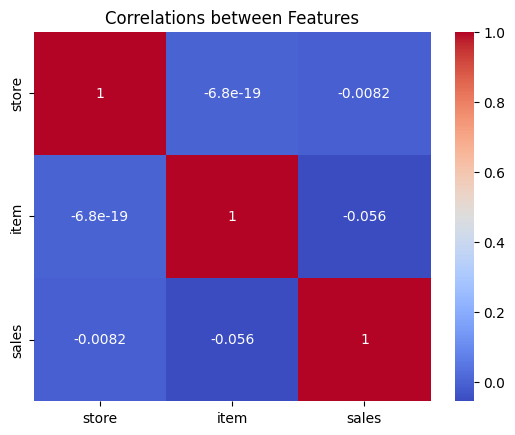

In [16]:
# Correlations between features
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlations between Features")
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>The correlation heatmap is not very informative here, since <b>store</b> and <b>item</b> are categorical identifiers rather than continuous numeric features.</li>
        <li>A more meaningful view of relationships comes from grouped aggregations (store-wise and item-wise sales) and time-based trends, explored below.</li>
    </ol>
</div>

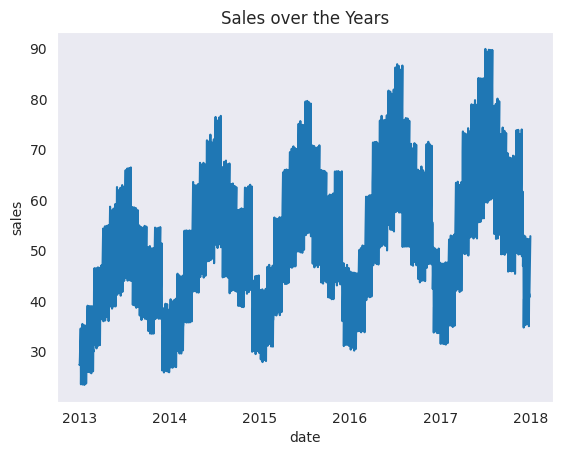

In [17]:
# Sales trend over the years
sns.set_style("dark")
sns.lineplot(
    data=df,
    x="date",
    y="sales",
    errorbar=None
)
plt.title("Sales over the Years")
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Clear upward trend, demand is increasing over the years.</li>
        <li>Strong seasonality with repeating yearly patterns.</li>
        <li>Sales peak around similar periods each year, suggesting a recurring seasonal driver (e.g. holidays or seasonal demand cycles).</li>
    </ol>
</div>

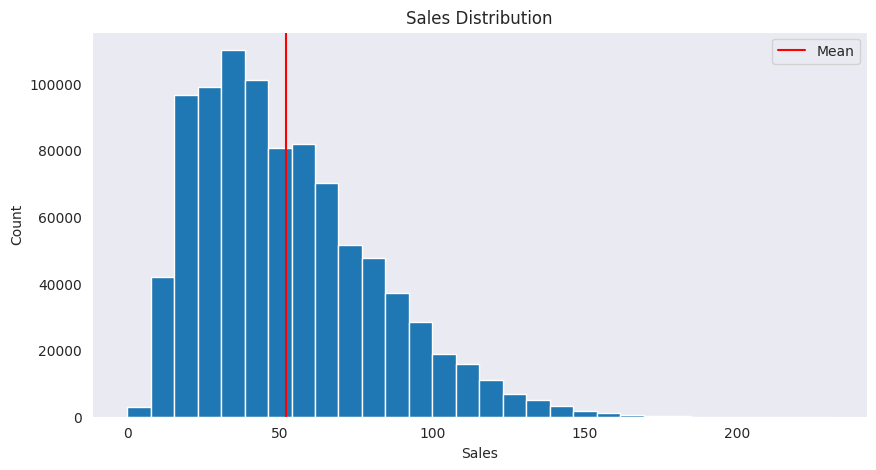

In [18]:
# Sales distribution
plt.figure(figsize=(10, 5))
plt.hist(df["sales"], bins=30)
sales_mean = df["sales"].mean()
plt.axvline(x=sales_mean, color="red", label="Mean")
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Count")
plt.legend()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Most days see moderate sales, roughly in the 0–100 unit range.</li>
        <li>A smaller share of days spike to 100–180+ units.</li>
        <li>The long tail of high sales values makes the distribution right-skewed.</li>
        <li>This indicates high sales volumes occur less frequently, while lower/moderate sales volumes dominate the dataset.</li>
    </ol>
</div>

In [19]:
df.groupby("store")["sales"].mean()

store
1     47.268379
2     67.033165
3     59.530602
4     54.902946
5     39.770164
6     39.733516
7     36.363735
8     64.142048
9     55.049025
10    58.709288
Name: sales, dtype: float64

In [20]:
df.groupby("item")["sales"].mean()

item
1     21.981599
2     58.574151
3     36.642223
4     22.010241
5     18.358708
6     58.503888
7     58.531051
8     76.950055
9     51.389869
10    73.227437
11    69.656353
12    69.634940
13    84.316594
14    58.681873
15    88.030778
16    25.656079
17    32.994852
18    84.275794
19    40.355531
20    47.515936
21    40.317087
22    80.502245
23    29.297864
24    66.044633
25    80.686418
26    47.644085
27    22.049726
28    87.881325
29    69.618839
30    40.337021
31    58.644304
32    43.981763
33    69.560953
34    25.735761
35    65.801807
36    77.028916
37    29.258379
38    80.521906
39    43.883406
40    29.249398
41    22.002136
42    36.688116
43    51.294359
44    29.398193
45    80.584173
46    58.639869
47    22.003341
48    51.352848
49    29.335323
50    65.882202
Name: sales, dtype: float64

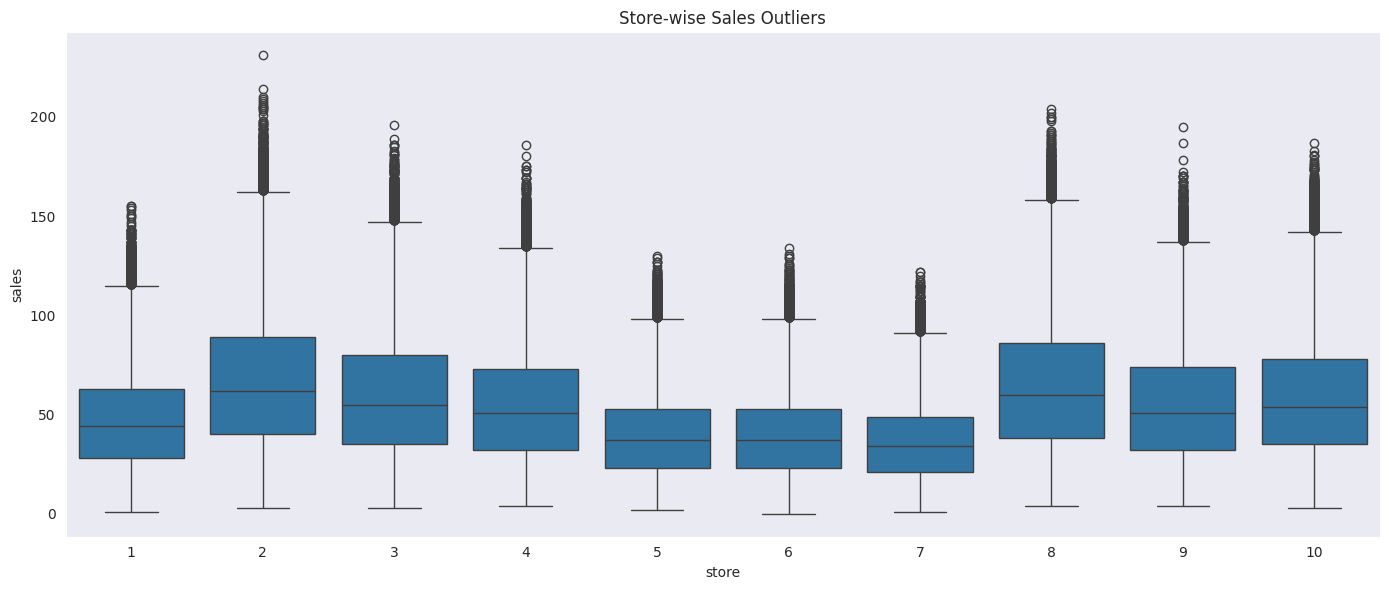

In [21]:
plt.figure(figsize=(14, 6))
sns.boxplot(x="store", y="sales", data=df)
plt.title("Store-wise Sales Outliers")
plt.tight_layout()
plt.show()

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 15px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 15px; display: block; margin-bottom: 5px;">💡 Key Insight:</span>
    <ol style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li>Every store shows outliers, so these are not isolated data errors but a genuine feature of the sales pattern.</li>
        <li>Outliers should not be removed, they likely reflect real high-demand days (promotions, holidays, restocking cycles).</li>
        <li>Store-level differences in sales (see the store-wise mean above) confirm that <b>store</b> is an important feature, and modeling should account for store-specific behavior.</li>
    </ol>
</div>

<div style="border-left: 6px solid #73d2de; background-color: #EFFAFB; padding: 10px 15px; border-radius: 0 8px 8px 0; margin-top: 30px; margin-bottom: 15px;">
    <h2 style="color: #2B2D42; margin: 0; font-family: 'Segoe UI', sans-serif; font-size: 22px; font-weight: 600;">4. EDA Conclusion</h2>
</div>

<div style="background-color: #F0F4F8; border-left: 5px solid #102A43; padding: 18px 20px; border-radius: 4px; margin: 15px 0; box-shadow: 0 2px 5px rgba(0,0,0,0.05);">
    <span style="font-weight: bold; color: #102A43; font-size: 16px; display: block; margin-bottom: 10px;">📌 Summary of Findings</span>
    <ul style="margin: 0; padding-left: 20px; color: #334E68; font-size: 14px; line-height: 1.7;">
        <li><b>The dataset is clean.</b> 913,000 rows across 10 stores, 50 items, and 1826 days (2013–2017), with no missing values and no duplicates.</li>
        <li><b>Demand is trending upward with strong seasonality.</b> Sales show a clear year-over-year increase along with repeating yearly seasonal patterns.</li>
        <li><b>Sales are right-skewed.</b> Most days fall in a moderate 0–100 unit range, with a long tail of high-sales days pulling the distribution to the right.</li>
        <li><b>Store and item both matter.</b> Average sales vary meaningfully across stores and items, and item 15 leads in total volume both should be treated as key predictive features.</li>
        <li><b>Outliers are genuine signal, not noise.</b> Every store shows sales outliers on the boxplot, so these are kept in the data rather than removed, and store-specific modeling is recommended.</li>
    </ul>
</div>

<div style="background: linear-gradient(135deg, #73d2de 0%, #218fa3 100%); padding: 20px 25px; border-radius: 10px; box-shadow: 0 4px 15px rgba(0,0,0,0.15); margin: 20px 0;">
    <p style="color: white; font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; margin: 0; font-size: 15px; line-height: 1.6;">
        <b>Takeaway:</b> The EDA confirms this is a well-structured, clean time-series problem with clear trend and seasonal components. Store and item identity both meaningfully influence sales volume, and the right-skewed, outlier-rich distribution points toward models that can capture seasonality and non-linear store/item effects such as tree-based ensembles (XGBoost, LightGBM) or time-series-aware approaches (e.g. LSTM) over simple linear baselines.
    </p>
</div>